# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [5]:
cleaned_df = pd.read_csv('data/aviation_accidents_cleaned.csv')
cleaned_df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_9052\2614924360.py:1: DtypeWarning: Columns (0,26) have mixed types. Specify dtype option on import or set low_memory=False.
  cleaned_df = pd.read_csv('data/aviation_accidents_cleaned.csv')


,event_id,investigation_type,accident_number,event_date,location,country,latitude,longitude,airport_code,airport_name,...,total_uninjured,weather_condition,broad_phase_of_flight,report_status,publication_date,total_passengers,serious_fatal_injuries,injury_rate,aircraft_destroyed,make_model
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,NaN,NaN,LAX,LOS ANGELES INTL,...,588.0,VMC,taxi,Probable Cause,04-12-2014,588.0,0.0,0.0,0,BOEING_747
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,0.0,IMC,cruise,Probable Cause,02-05-2011,2.0,2.0,1.0,1,PIPER_pa-28-140
2,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,NaN,NaN,TX05,AERO COUNTRY,...,4.0,VMC,standing,Probable Cause,17-10-2016,5.0,1.0,0.2,0,DE_HAVILLAND_dhc-6
3,20001214X45013,Incident,CHI84IA041,1983-11-08,"CHICAGO, IL",United States,NaN,NaN,ORD,O'HARE,...,100.0,VMC,taxi,Probable Cause,11-06-2018,100.0,0.0,0.0,0,BOEING_727-200
4,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,NaN,NaN,NaN,NaN,...,1.0,VMC,climb,Probable Cause,05-05-2011,1.0,0.0,0.0,0,BEECH_c35


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [6]:
cleaned_df['aircraft_size'] = np.where(cleaned_df['total_passengers'] < 20, 'Small', 'Large')

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [16]:
cleaned_df.columns

Index(['event_id', 'investigation_type', 'accident_number', 'event_date',
       'location', 'country', 'latitude', 'longitude', 'airport_code',
       'airport_name', 'injury_severity', 'aircraft_damage',
       'aircraft_category', 'registration_number', 'make', 'model',
       'amateur_built', 'number_of_engines', 'engine_type', 'far_description',
       'purpose_of_flight', 'total_fatal_injuries', 'total_serious_injuries',
       'total_minor_injuries', 'total_uninjured', 'weather_condition',
       'broad_phase_of_flight', 'report_status', 'publication_date',
       'total_passengers', 'serious_fatal_injuries', 'injury_rate',
       'aircraft_destroyed', 'make_model', 'aircraft_size'],
      dtype='object')

In [43]:
#Compute Mean Injury Rate by Make
# Compute Mean Injury Rate by Make
make_statistics = cleaned_df.groupby(['aircraft_size', 'make']).agg(
    injury_rate=('injury_rate', 'mean'),
    destroyed=('aircraft_destroyed', 'mean'),
    count=('make', 'size')   # Count of accidents for each make
).reset_index()

# Filter for statistical robustness
make_statistics = make_statistics[make_statistics['count'] >= 50]

In [44]:
# Cleaner Naming for Analysis
make_statistics = make_statistics.rename(columns={
    'make': 'Make',
    'injury_rate': 'Mean_Injury_Rate',
    'destroyed': 'Destruction_Rate'
})

In [47]:
# Identify Top 15 Makes by Injury Rate for Each Aircraft Size
small_aircraft_makes = make_statistics[make_statistics['aircraft_size'] == 'Small'].nsmallest(15, 'Mean_Injury_Rate')
large_aircraft_makes = make_statistics[make_statistics['aircraft_size'] == 'Large'].nsmallest(15, 'Mean_Injury_Rate')

C:\Users\Admin\AppData\Local\Temp\ipykernel_9052\2862509126.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_9052\2862509126.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


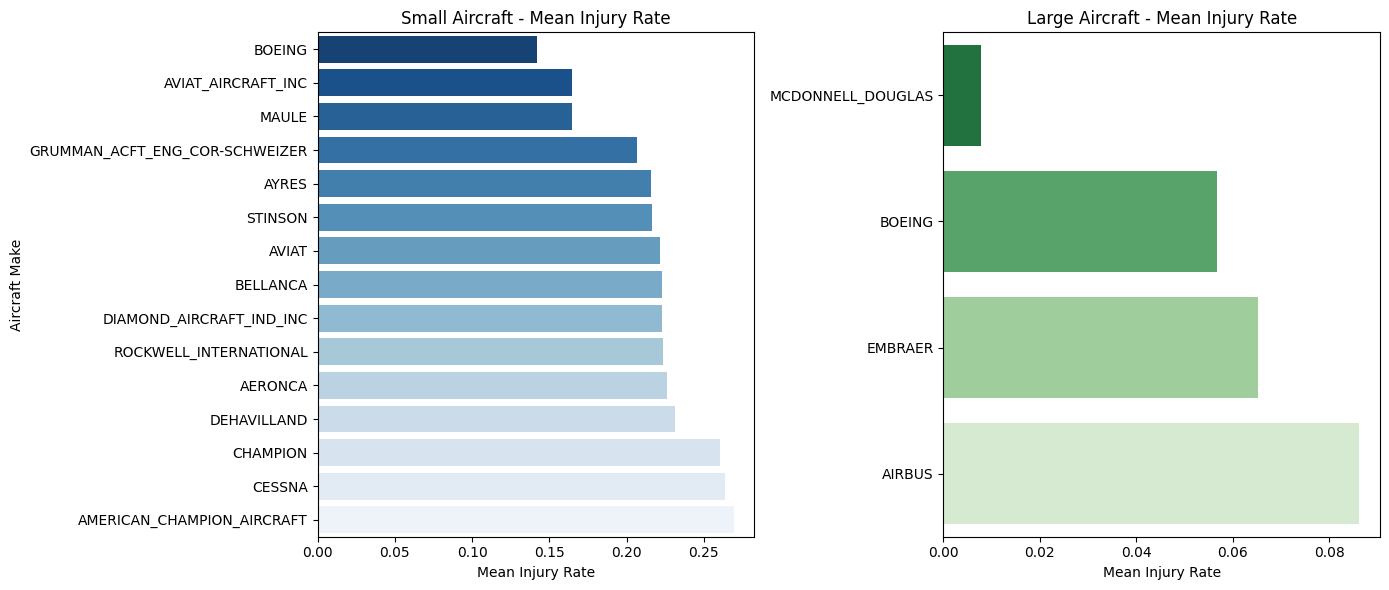

In [48]:
#Visualization: Injury Rate by Make
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.barplot(
    data=small_aircraft_makes.sort_values('Mean_Injury_Rate'),
    x='Mean_Injury_Rate',
    y='Make',
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('Small Aircraft - Mean Injury Rate')
axes[0].set_xlabel('Mean Injury Rate')
axes[0].set_ylabel('Aircraft Make')

sns.barplot(
    data=large_aircraft_makes.sort_values('Mean_Injury_Rate'),
    x='Mean_Injury_Rate',
    y='Make',
    ax=axes[1],
    palette='Greens_r'
)
axes[1].set_title('Large Aircraft - Mean Injury Rate')
axes[1].set_xlabel('Mean Injury Rate')
axes[1].set_ylabel('')

plt.tight_layout()
   

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [ ]:
# Display Top 10 Safest Small Aircraft Makes
top_10_safest_small_aircraft_makes = small_aircraft_makes.sort_values('Mean_Injury_Rate').head(10) 
top_10_safest_small_aircraft_makes

,aircraft_size,Make,Mean_Injury_Rate,Destruction_Rate,count
23,Small,BOEING,0.141973,0.080882,272
19,Small,AVIAT_AIRCRAFT_INC,0.164474,0.039474,76
37,Small,MAULE,0.164806,0.041860,215
35,Small,GRUMMAN_ACFT_ENG_COR-SCHWEIZER,0.206897,0.017241,58
20,Small,AYRES,0.215686,0.117647,51
45,Small,STINSON,0.216408,0.023256,129
18,Small,AVIAT,0.221429,0.100000,70
22,Small,BELLANCA,0.222603,0.050228,219
31,Small,DIAMOND_AIRCRAFT_IND_INC,0.222973,0.054054,74
43,Small,ROCKWELL_INTERNATIONAL,0.223684,0.122807,57


In [ ]:
# Another way to get the top 10 safest small aircraft makes
top_10_safest_small_aircraft_makes = (
    make_statistics[make_statistics['aircraft_size'] == 'Small']
    .nsmallest(10, 'Mean_Injury_Rate')['Make']
)
top_10_safest_small_aircraft_makes

23                            BOEING
19                AVIAT_AIRCRAFT_INC
37                             MAULE
35    GRUMMAN_ACFT_ENG_COR-SCHWEIZER
20                             AYRES
45                           STINSON
18                             AVIAT
22                          BELLANCA
31          DIAMOND_AIRCRAFT_IND_INC
43            ROCKWELL_INTERNATIONAL
Name: Make, dtype: object

C:\Users\Admin\AppData\Local\Temp\ipykernel_9052\402399758.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Text(0.5, 1.0, 'Distribution of Injury Rates (Top 10 Small Aircraft Makes)')

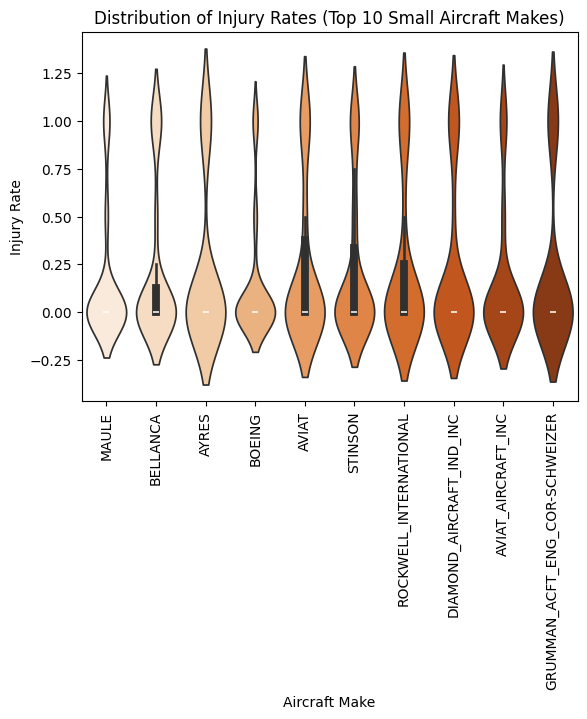

In [ ]:
# Violin Plot for Injury Rate Distribution of Top 10 Safest Small Aircraft Makes
sns.violinplot(
    data=cleaned_df[(cleaned_df['make'].isin(top_10_safest_small_aircraft_makes)) & (cleaned_df['aircraft_size'] == 'Small')],
    x='make',
    y='injury_rate',
    palette='Oranges'
)
plt.xticks(rotation=90)
plt.xlabel('Aircraft Make')
plt.ylabel('Injury Rate')
plt.title('Distribution of Injury Rates (Top 10 Small Aircraft Makes)')

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [70]:
# Display Top 10 Safest Large Aircraft Makes
top_10_safest_large_aircraft_makes = large_aircraft_makes.sort_values('Mean_Injury_Rate').head(10) 
top_10_safest_large_aircraft_makes

,aircraft_size,Make,Mean_Injury_Rate,Destruction_Rate,count
9,Large,MCDONNELL_DOUGLAS,0.007827,0.075472,53
2,Large,BOEING,0.056771,0.049360,547
7,Large,EMBRAER,0.065274,0.051282,78
0,Large,AIRBUS,0.086249,0.076271,118


In [ ]:
# Another way to get the top 10 safest large aircraft makes
top_10_safest_large_aircraft_makes = (
    make_statistics[make_statistics['aircraft_size'] == 'Large']
    .nsmallest(10, 'Mean_Injury_Rate')['Make']
)

top_10_safest_large_aircraft_makes

9    MCDONNELL_DOUGLAS
2               BOEING
7              EMBRAER
0               AIRBUS
Name: Make, dtype: object

Text(0.5, 1.0, 'Injury Rate Distribution - Large Aircraft (Top 10 Safest Makes)')

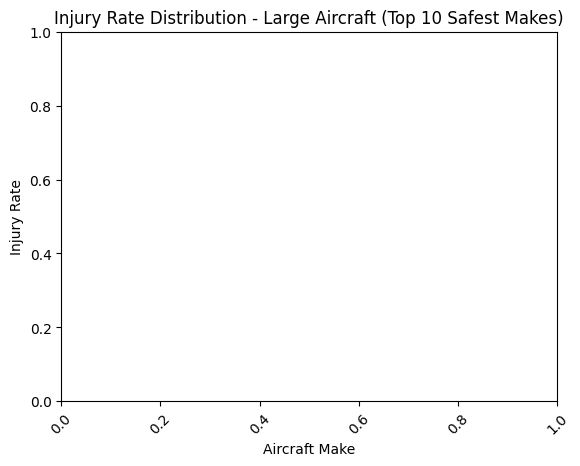

In [72]:
# Distribution: Large Aircraft (Strip Plot)
sns.stripplot(
    data=cleaned_df[
        (cleaned_df['make'].isin(top_10_safest_large_aircraft_makes)) &
        (cleaned_df['aircraft_size'] == 'Large')
    ],
    x='make',
    y='injury_rate',
    jitter=True
)

plt.xticks(rotation=45)
plt.xlabel('Aircraft Make')
plt.ylabel('Injury Rate')
plt.title('Injury Rate Distribution - Large Aircraft (Top 10 Safest Makes)')


A stripplot was initially considered to visualize injury rate distributions across aircraft manufacturers. However, given the limited number of qualifying manufacturers and uneven sample sizes across groups, the stripplot produced excessive overplotting and limited interpretability. Therefore, a boxplot was used instead, as it provides a clearer summary of the distribution by highlighting the median, interquartile range, and potential outliers for each manufacturer. This allows for more effective comparison of injury rate distributions across aircraft makes.

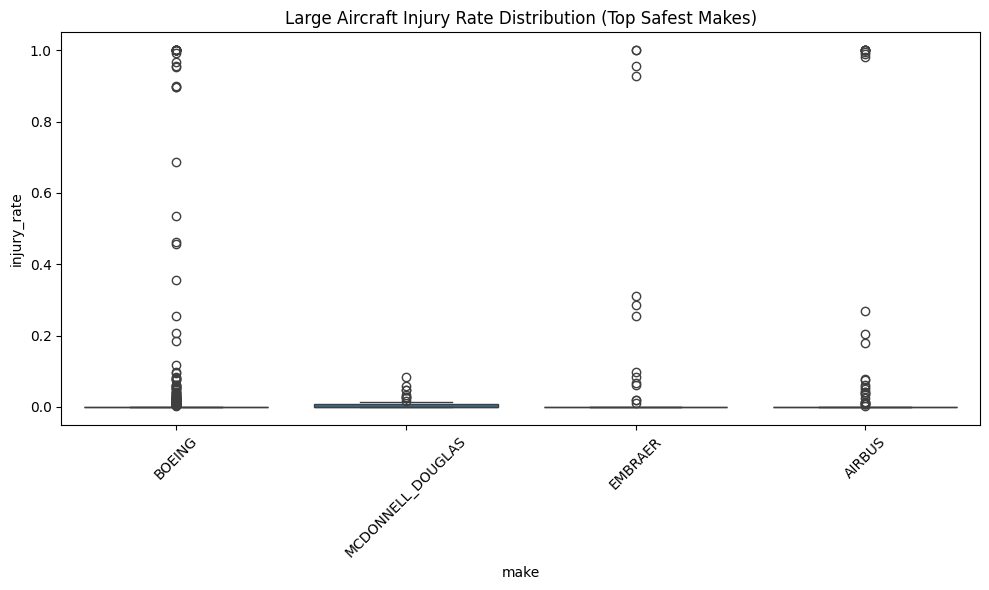

In [ ]:
# Box Plot for Large Aircraft Injury Rate Distribution
plt.figure(figsize=(10,6))

sns.boxplot(
    data=cleaned_df[
        (cleaned_df['make'].isin(top_10_safest_large_aircraft_makes)) &
        (cleaned_df['aircraft_size'] == 'Large')
    ],
    x='make',
    y='injury_rate'
)

plt.xticks(rotation=45)
plt.title('Large Aircraft Injury Rate Distribution (Top Safest Makes)')
plt.tight_layout()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [ ]:
# Get top 15 makes with lowest destruction rate for each aircraft size
destruction_rates = (
    make_statistics
    .groupby('aircraft_size', group_keys=False)
    .apply(lambda x: x.nsmallest(15, 'Destruction_Rate')) # Lambda function to get top 15 by destruction rate within each aircraft size
)

destruction_rates

C:\Users\Admin\AppData\Local\Temp\ipykernel_9052\2129732814.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nsmallest(15, 'Destruction_Rate'))


,aircraft_size,Make,Mean_Injury_Rate,Destruction_Rate,count
2,Large,BOEING,0.056771,0.049360,547
7,Large,EMBRAER,0.065274,0.051282,78
9,Large,MCDONNELL_DOUGLAS,0.007827,0.075472,53
0,Large,AIRBUS,0.086249,0.076271,118
36,Small,LUSCOMBE,0.280142,0.014184,141
35,Small,GRUMMAN_ACFT_ENG_COR-SCHWEIZER,0.206897,0.017241,58
45,Small,STINSON,0.216408,0.023256,129
46,Small,TAYLORCRAFT,0.306452,0.032258,93
12,Small,AERONCA,0.225833,0.035000,200
17,Small,AMERICAN_CHAMPION_AIRCRAFT,0.269231,0.038462,52


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

Observations:  
Certain manufacturers consistently show lower injury rates and destruction probabilities, making them strong candidates for safer aircraft.
Small aircraft tend to show higher variability in injury outcomes, likely due to differences in usage and operating conditions.
Large aircraft generally demonstrate more consistent safety performance, possibly due to stricter regulations and engineering redundancy.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [85]:
# Step 1: Compute mean injury rate by aircraft size
mean_injury_rate_by_size = cleaned_df.groupby('aircraft_size')['injury_rate'].mean().reset_index()
mean_injury_rate_by_size

,aircraft_size,injury_rate
0,Large,0.061187
1,Small,0.286981


C:\Users\Admin\AppData\Local\Temp\ipykernel_9052\850965908.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


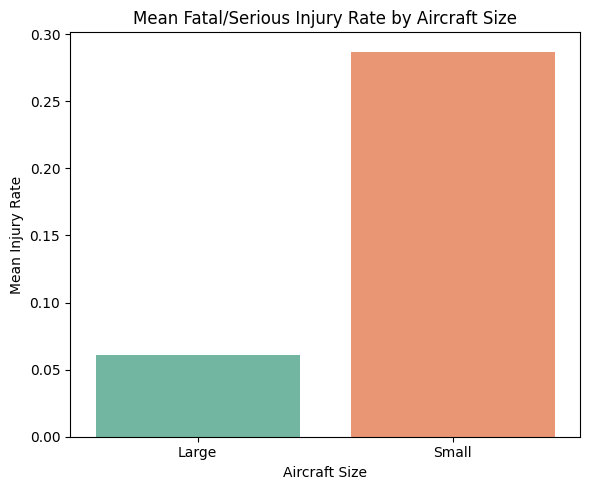

In [88]:
# Step 2: Plot comparison
#Bar plot (best for comparing two groups)
plt.figure(figsize=(6,5))

sns.barplot(
    data=mean_injury_rate_by_size,
    x='aircraft_size',
    y='injury_rate',
    palette='Set2'
)

plt.title('Mean Fatal/Serious Injury Rate by Aircraft Size')
plt.xlabel('Aircraft Size')
plt.ylabel('Mean Injury Rate')
plt.tight_layout()

C:\Users\Admin\AppData\Local\Temp\ipykernel_9052\4269837732.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


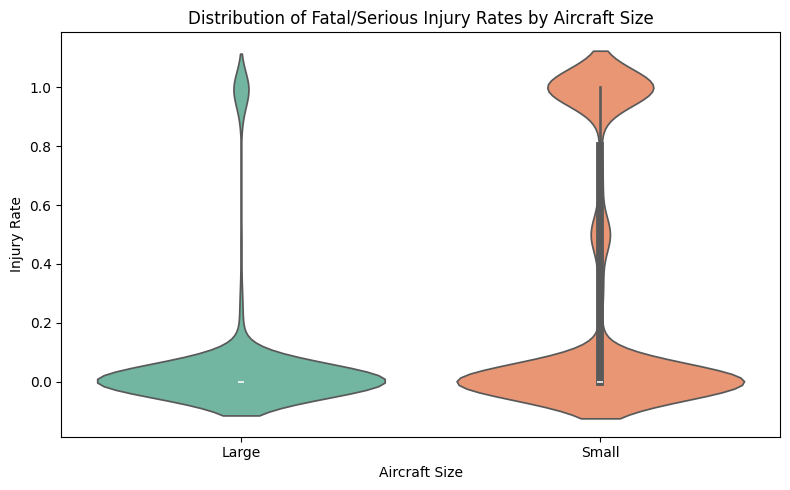

In [ ]:
# Violin plot by aircraft size (best for showing distribution differences)
plt.figure(figsize=(8,5))

sns.violinplot(
    data=cleaned_df,
    x='aircraft_size',
    y='injury_rate',
    palette='Set2'
)

plt.title('Distribution of Fatal/Serious Injury Rates by Aircraft Size')
plt.xlabel('Aircraft Size')
plt.ylabel('Injury Rate')
plt.tight_layout()

The distributional plot shows that small aircraft exhibit greater variability in fatal and serious injury rates compared to large aircraft. This suggests that small aircraft safety is more sensitive to operational and environmental conditions. In contrast, large aircraft show a more concentrated distribution with lower variability, indicating more consistent safety performance across incidents.

### filter ensuring that you have at least ten individual examples in each model/make to average over

In [94]:
# Small aircraf
small_valid_models = (
    cleaned_df[cleaned_df['aircraft_size'] == 'Small']
    .groupby('make_model')
    .filter(lambda x: len(x) >= 10)
)
small_valid_models.head()

,event_id,investigation_type,accident_number,event_date,location,country,latitude,longitude,airport_code,airport_name,...,weather_condition,broad_phase_of_flight,report_status,publication_date,total_passengers,serious_fatal_injuries,injury_rate,aircraft_destroyed,make_model,aircraft_size
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,IMC,cruise,Probable Cause,02-05-2011,2.0,2.0,1.0,1,PIPER_pa-28-140,Small
4,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,NaN,NaN,NaN,NaN,...,VMC,climb,Probable Cause,05-05-2011,1.0,0.0,0.0,0,BEECH_c35,Small
5,20001214X45339,Accident,LAX84LA110,1983-12-22,"SANTA ROSA ISLAND, CA",United States,NaN,NaN,NaN,PRIVATE,...,VMC,takeoff,Probable Cause,01-02-2016,1.0,0.0,0.0,0,CESSNA_180k,Small
6,20001214X38957,Accident,ATL84LA120,1984-03-14,"MYRTLE BEACH, SC",United States,NaN,NaN,CRE,GRAND STRAND,...,VMC,landing,Probable Cause,24-09-2018,1.0,0.0,0.0,0,BEECH_99,Small
7,20001214X40033,Accident,MIA84LA182,1984-06-11,"FT. LAUDERDALE, FL",United States,NaN,NaN,FXE,FT. LAUDERDALE EXECUTIVE,...,VMC,approach,Probable Cause,13-09-2011,4.0,0.0,0.0,0,PIPER_pa-23-250,Small


In [96]:
# Large aircraft
large_valid_models = (
    cleaned_df[cleaned_df['aircraft_size'] == 'Large']
    .groupby('make_model')
    .filter(lambda x: len(x) >= 10)
)
large_valid_models.tail()

,event_id,investigation_type,accident_number,event_date,location,country,latitude,longitude,airport_code,airport_name,...,weather_condition,broad_phase_of_flight,report_status,publication_date,total_passengers,serious_fatal_injuries,injury_rate,aircraft_destroyed,make_model,aircraft_size
16590,20220623105316,Incident,ENG22WA032,2022-06-14,"Karachi,",Pakistan,245423N,0067952E,NaN,NaN,...,NaN,NaN,NaN,01-09-2022,183.0,0.0,0.000000,0,BOEING_777,Large
16699,20220719105521,Accident,DCA22WA152,2022-07-16,"Naha,",Japan,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,19-07-2022,133.0,0.0,0.000000,0,BOEING_737,Large
16868,20220922105982,Incident,DCA22WA206,2022-09-03,"Zurich,",Switzerland,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,01-12-2022,120.0,0.0,0.000000,0,BOEING_737,Large
16941,20221003106034,Incident,DCA23WA002,2022-10-01,"Manila,",Philippines,143553N,0120591E,RPLL,Ninoy Aquino International Air,...,NaN,NaN,NaN,12-10-2022,368.0,0.0,0.000000,0,BOEING_777,Large
16949,20221011106104,Accident,DCA23WA012,2022-10-03,"Komatsu, Ishikawa, OF",Japan,362338N,1362427E,NaN,NaN,...,NaN,NaN,NaN,11-10-2022,106.0,1.0,0.009434,0,BOEING_737,Large


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [97]:
# Step 1: Filter to small aircraft
small_aircraft_data = cleaned_df[cleaned_df['aircraft_size'] == 'Small']

In [107]:
# Compute mean injury rate by make
mean_injury_rate_by_make = (
    small_aircraft_data
    .groupby('make')
    .agg(mean_injury_rate=('injury_rate', 'mean'))
    .reset_index()
)

In [109]:
# Step 3: Select 10 safest makes
top_10_safest_small_aircraft_makes = (
    mean_injury_rate_by_make
    .sort_values('mean_injury_rate')
    .head(10)['make']
)

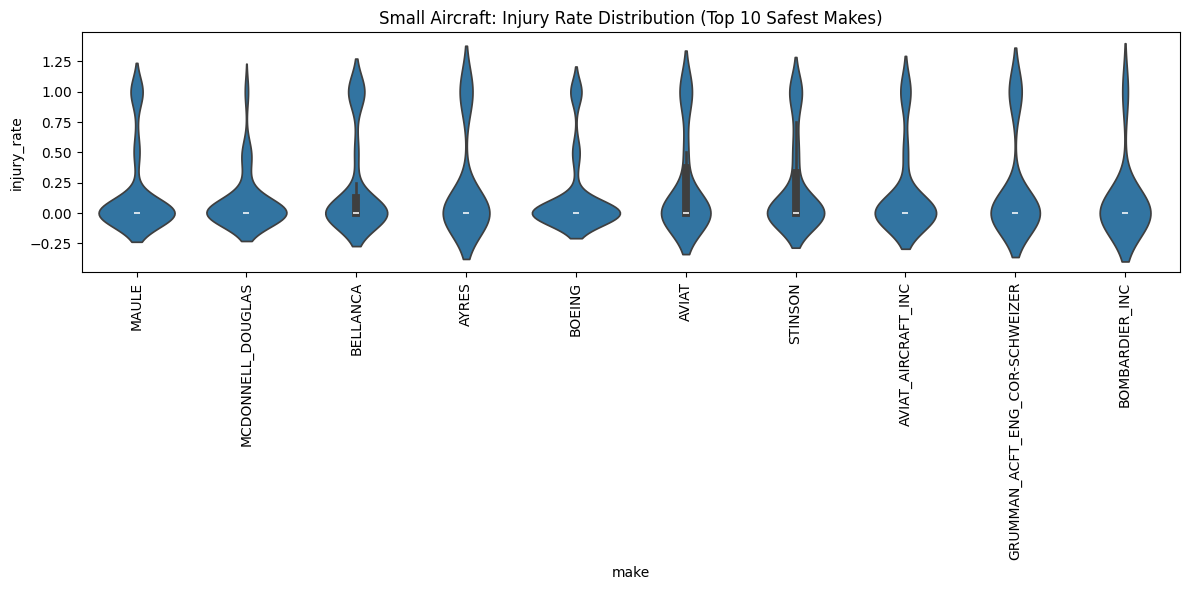

In [110]:
# Violin plot for top 10 safest small aircraft makes
plt.figure(figsize=(12,6))

sns.violinplot(
    data=small_aircraft_data[
        small_aircraft_data['make'].isin(top_10_safest_small_aircraft_makes)
    ],
    x='make',
    y='injury_rate'
)

plt.xticks(rotation=90)
plt.title('Small Aircraft: Injury Rate Distribution (Top 10 Safest Makes)')
plt.tight_layout()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

The results suggest that aircraft size is a strong structural factor in passenger safety outcomes. Large aircraft tend to offer more consistent protection against severe injury in accident scenarios, while small aircraft outcomes are more heterogeneous and influenced by a broader set of operational variables.

This supports the idea that safety in aviation is not only dependent on manufacturer or model, but also strongly shaped by aircraft category and its associated operational context.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [ ]:
# Factor 1: Weather Conditions
weather_stats = (
    cleaned_df
    .groupby('weather_condition')
    .agg(
        mean_injury_rate=('injury_rate', 'mean'),
        mean_destruction_rate=('aircraft_destroyed', 'mean'),
        count=('injury_rate', 'size')
    )
    .reset_index()
)

# Keep statistically reliable groups
weather_stats = weather_stats[weather_stats['count'] >= 100]

# Sort for visualization
weather_stats = weather_stats.sort_values('mean_injury_rate')

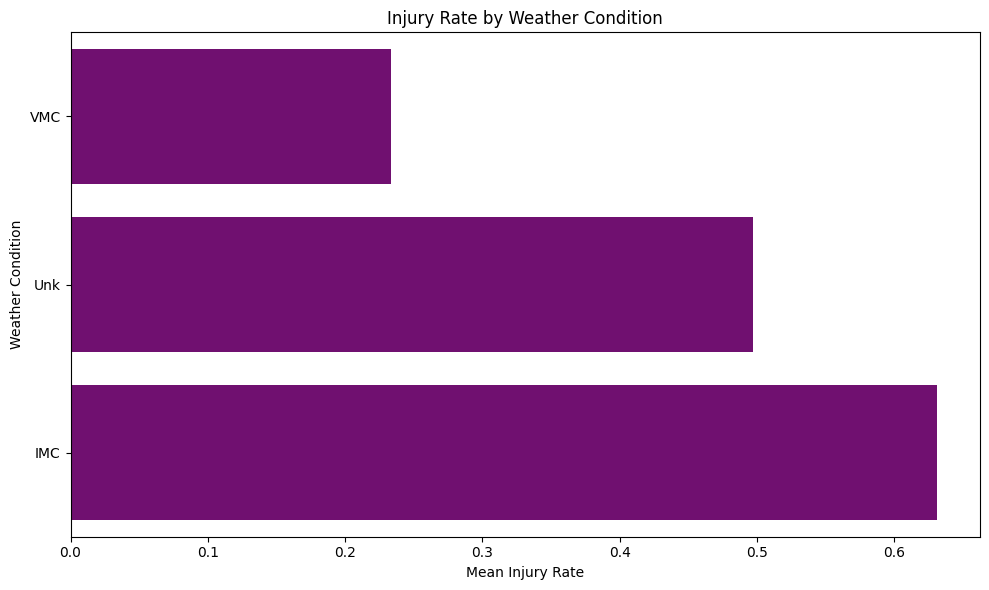

In [122]:
# Visualization: Injury Rate by Weather Condition
plt.figure(figsize=(10,6))

sns.barplot(
    data=weather_stats,
    x='mean_injury_rate',
    y='weather_condition',
    color='purple'
)

plt.title('Injury Rate by Weather Condition')
plt.xlabel('Mean Injury Rate')
plt.ylabel('Weather Condition')
plt.tight_layout()

Observation: 
Weather conditions show variation in average injury severity across categories. However, after applying a minimum sample threshold, the differences become more stable and less influenced by rare events. Adverse weather conditions are generally associated with higher injury rates, but the effect is not extreme, suggesting that modern aviation systems mitigate weather-related risks effectively.

In [116]:
# Factor 2: Engine Type
phase_stats = (
    cleaned_df
    .groupby('broad_phase_of_flight')
    .agg(
        mean_injury_rate=('injury_rate', 'mean'),
        mean_destruction_rate=('aircraft_destroyed', 'mean'),
        count=('injury_rate', 'size')
    )
    .reset_index()
)

In [117]:
phase_stats = phase_stats[phase_stats['count'] >= 100]

In [118]:
phase_stats = phase_stats.sort_values('mean_injury_rate')

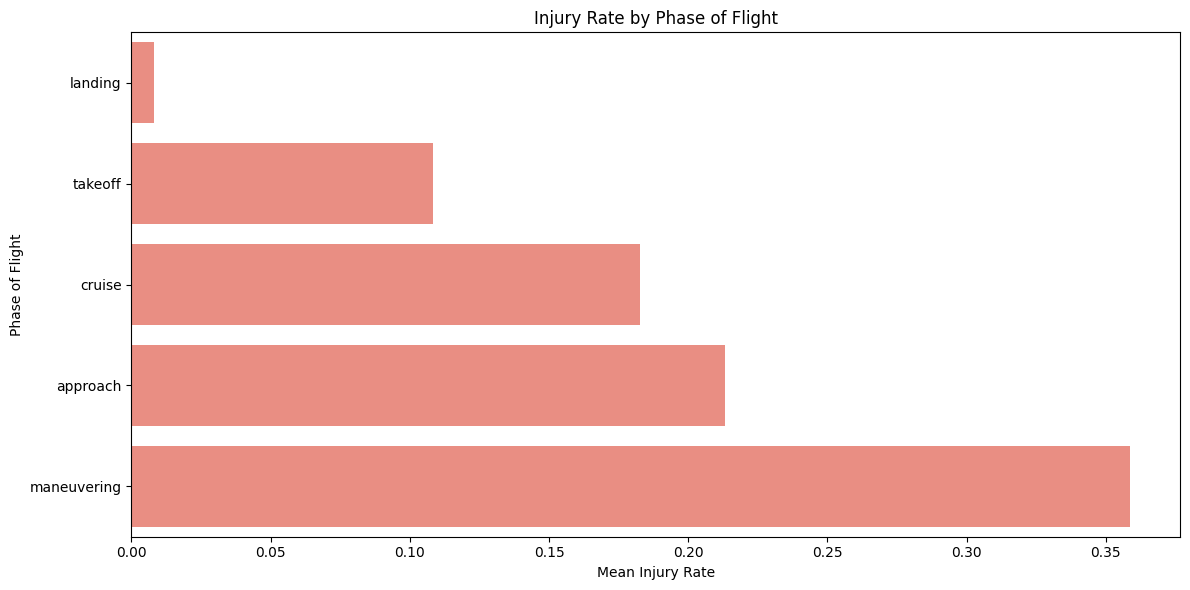

In [121]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=phase_stats,
    x='mean_injury_rate',
    y='broad_phase_of_flight',
    color='salmon'
)

plt.title('Injury Rate by Phase of Flight')
plt.xlabel('Mean Injury Rate')
plt.ylabel('Phase of Flight')
plt.tight_layout()

The phase of flight shows variation in injury severity across different stages of flight operations. Certain phases, particularly takeoff and landing, tend to exhibit higher injury rates compared to cruise phases. This is consistent with aviation safety literature, which identifies takeoff and landing as the most critical phases due to low altitude, limited reaction time, and higher operational complexity.

However, after applying a minimum sample threshold, the differences become more reliable and reflect systematic operational risk rather than isolated incidents.

## Final Conclusion: Aviation Safety Analysis (1948–2023)

This analysis examined aviation accident data to identify aircraft makes, models, and operational conditions associated with lower rates of fatal/serious injury and aircraft destruction. The goal was to support recommendations for safer aircraft selection, separated by small and large aircraft categories, while ensuring statistical reliability through minimum sample size filtering and restricted time relevance (post-1983 aircraft activity window).

### Aircraft size and manufacturer differences

A clear distinction emerges between small and large aircraft in terms of safety performance. Large aircraft consistently demonstrate lower and more stable fatal/serious injury rates, with tighter distributions across manufacturers. This suggests that commercial aviation benefits from stronger regulatory oversight, more redundant safety systems, and standardized operational procedures.

In contrast, small aircraft show significantly higher variability in injury outcomes across makes and models. Even among the safest small aircraft manufacturers, outcomes are less consistent, reflecting greater sensitivity to external factors such as pilot experience, usage context, and environmental conditions.

### Destruction risk patterns

Aircraft destruction rates also vary meaningfully across manufacturers. Large aircraft generally exhibit lower destruction probabilities, reinforcing the role of structural design standards and certification requirements in improving survivability. Small aircraft, while more variable, still show identifiable manufacturers with comparatively strong safety performance.

### Operational and environmental factors

Beyond aircraft design, operational conditions also influence safety outcomes. Phase of flight is the most significant factor, with takeoff and landing consistently associated with higher injury severity compared to cruise phases. Weather conditions and engine type show more moderate effects, though their influence is less pronounced once minimum sample size thresholds are applied. These findings reinforce the idea that aviation risk is primarily driven by operational context rather than isolated technical variables.

### Key insight

Overall, the analysis demonstrates that aviation safety is the result of interacting structural, operational, and environmental factors. Aircraft design (especially size category and manufacturer), combined with critical flight phases, plays a more substantial role in safety outcomes than any single environmental or mechanical variable alone.

### Final recommendation

For insurers and aviation stakeholders, the safest profiles are associated with:

* Large aircraft manufacturers with consistently low injury and destruction rates
* Small aircraft models with sufficiently large operational histories and low mean injury fractions
* Operational awareness of high-risk phases of flight, particularly takeoff and landing